In [ ]:
import os
import cv2
import numpy as np

In [2]:
dataset_path = "D:/Deep Learning/archive"

In [3]:
classes = ["cats", "dogs"]

In [16]:
import tensorflow as tf 
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,BatchNormalization,Dropout

Generators --->convert data into  batches 

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    directory="D:/Deep Learning/archive/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
    )

Found 20000 files belonging to 2 classes.


In [6]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory="D:/Deep Learning/archive/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
    )
    

Found 5000 files belonging to 2 classes.


Normalize 

In [7]:
def process(image,label):
    image =tf.cast(image/255. , tf.float32)
    return image, label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Create CNN Model

In [ ]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds, verbose=1, )

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 586s 935ms/step - accuracy: 0.6459 - loss: 0.6167 - val_accuracy: 0.7548 - val_loss: 0.5059
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 542s 866ms/step - accuracy: 0.7717 - loss: 0.4757 - val_accuracy: 0.7906 - val_loss: 0.4374
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 470s 752ms/step - accuracy: 0.8299 - loss: 0.3750 - val_accuracy: 0.8070 - val_loss: 0.4436
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 465s 744ms/step - accuracy: 0.8896 - loss: 0.2540 - val_accuracy: 0.8058 - val_loss: 0.4903
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 429s 686ms/step - accuracy: 0.9433 - loss: 0.1455 - val_accuracy: 0.8062 - val_loss: 0.7102
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 433s 693ms/step - accuracy: 0.9694 - loss: 0.0868 - val_accuracy: 0.7926 - val_loss: 0.8669
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 419s 670ms/step - accuracy: 0.9787 - loss: 0.0607 - val_accuracy: 0.8046 - val_loss: 0.9235
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 415s 664ms/step - accuracy: 0.9817 -

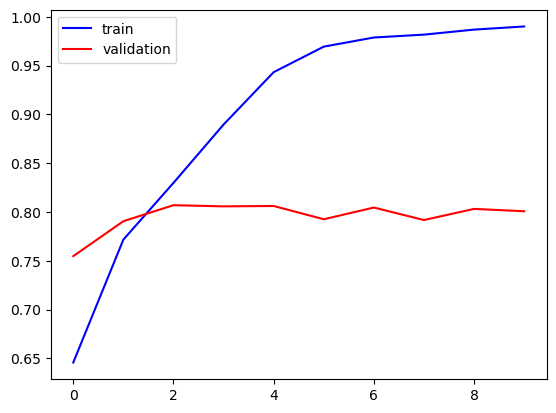

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='blue',label='train')
plt.plot(history.history['val_accuracy'],color='red',label='validation')
plt.legend()
plt.show()

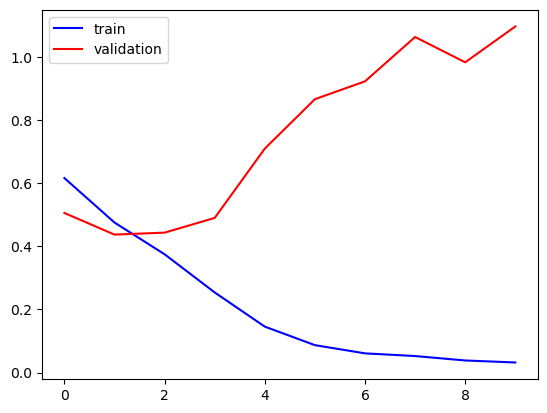

In [18]:
plt.plot(history.history['loss'],color='blue',label='train')
plt.plot(history.history['val_loss'],color='red',label='validation')
plt.legend()
plt.show()